# Magnification bias α — results summary

Loads the α measurements from `measurements/v2/DESI_magnification_bias_{QSO,LRG,ELG}.h5` and tabulates them per tracer, region, and redshift bin, alongside the derived magnification-bias slope parameter `s` used as an input to `Blast.jl` (arXiv:2410.03632).

In [1]:
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Maps each tracer to its output file, the HDF5 top-level key (note: ELG's key is `ELG_LOPnotqso`, not `ELG`), and the z-bin edges used by `calculate_magnification_bias_DESI.py`. Region list matches the spectroscopic configs' standing convention (`CLAUDE.md`).

In [2]:
RESULTS_DIR = "../measurements/v2/"

TRACERS = {
    "QSO": {"file": "DESI_magnification_bias_QSO.h5", "galaxy_type": "QSO",
            "zbins": [0.8, 2.1, 3.5]},
    "LRG": {"file": "DESI_magnification_bias_LRG.h5", "galaxy_type": "LRG",
            "zbins": [0.4, 1.1]},
    "ELG": {"file": "DESI_magnification_bias_ELG.h5", "galaxy_type": "ELG_LOPnotqso",
            "zbins": [1.1, 1.6]},
}

REGIONS = ["all", "north", "south", "des", "south+des"]

## Load results into a flat table

Each `.h5` file is nested `galaxy_type/region/{alphas, alphas_error, simple_alphas, simple_alphas_error}`, with each array indexed by z-bin. `alphas`/`alphas_error` are the full stepwise-fit estimate (the headline result); `simple_alphas`/`simple_alphas_error` are the single-κ sanity check.

The companion `..._full.h5` file additionally has the linear fit's goodness-of-fit per (region, z-bin), under `alphas/<galaxy_type>/<region>/<zbin index>/fit/`: `chi2`, `dof`, `red_chi2`, `PTE` (probability-to-exceed). A low PTE (e.g. well under a few percent) flags a z-bin/region where the linear-in-κ model doesn't describe the data well — usually smaller-N regions with noisier per-κ-step counts.

In [3]:
def load_tracer_results(tracer_name, meta):
    rows = []
    full_file = meta["file"].replace(".h5", "_full.h5")
    with h5py.File(RESULTS_DIR + meta["file"], "r") as f, \
         h5py.File(RESULTS_DIR + full_file, "r") as f_full:
        gtype = meta["galaxy_type"]
        if gtype not in f:
            print(f"Warning: {gtype} not found in {meta['file']}")
            return rows
        for region in REGIONS:
            if region not in f[gtype]:
                continue
            grp = f[gtype][region]
            alphas = grp["alphas"][()]
            alphas_err = grp["alphas_error"][()]
            simple_alphas = grp["simple_alphas"][()]
            simple_alphas_err = grp["simple_alphas_error"][()]

            full_grp = f_full["alphas"][gtype][region]

            zbins = meta["zbins"]
            for i in range(len(zbins) - 1):
                fit = full_grp[str(i)]["fit"]
                rows.append(dict(
                    tracer=tracer_name, region=region,
                    zmin=zbins[i], zmax=zbins[i + 1],
                    alpha=alphas[i], alpha_error=alphas_err[i],
                    simple_alpha=simple_alphas[i], simple_alpha_error=simple_alphas_err[i],
                    chi2=fit["chi2"][()], dof=int(fit["dof"][()]),
                    red_chi2=fit["red_chi2"][()], PTE=fit["PTE"][()],
                ))
    return rows


all_rows = []
for tracer_name, meta in TRACERS.items():
    all_rows += load_tracer_results(tracer_name, meta)

df = pd.DataFrame(all_rows)
len(df)

20

## Compute s = 0.4·α (magnification bias slope)

`Blast.jl`'s `MagnificationBias` kernel (`src/probes.jl`) weights by `(5s − 2)`; combined with the `(α − 1) × 2κ` magnification term in this repo's own convention (`CLAUDE.md`), the two describe the same physical effect when `s = (2/5)·α`. Applied here to both the stepwise (`alpha`) and simple (`simple_alpha`) estimates, propagating the error the same linear way.

In [4]:
df["s"] = 0.4 * df["alpha"]
df["s_error"] = 0.4 * df["alpha_error"]
df["simple_s"] = 0.4 * df["simple_alpha"]
df["simple_s_error"] = 0.4 * df["simple_alpha_error"]

## Summary table

One row per (tracer, region, z-bin) — 2×5 + 3×5 + 1×5 = 30 rows for the 3 spectroscopic tracers currently measured.

In [5]:
tracer_order = {"QSO": 0, "LRG": 1, "ELG": 2}
region_order = {r: i for i, r in enumerate(REGIONS)}

df_sorted = (
    df.assign(_t=df["tracer"].map(tracer_order), _r=df["region"].map(region_order))
      .sort_values(["_t", "_r", "zmin"])
      .drop(columns=["_t", "_r"])
      .reset_index(drop=True)
)

summary_table = df_sorted[["tracer", "region", "zmin", "zmax", "alpha", "alpha_error", "s", "s_error",
                            "chi2", "dof", "red_chi2", "PTE"]]
summary_table

,tracer,region,zmin,zmax,alpha,alpha_error,s,s_error,chi2,dof,red_chi2,PTE
0,QSO,all,0.8,2.1,0.250225,0.003674,0.100090,0.001469,28.854154,13,2.219550,0.006865
1,QSO,all,2.1,3.5,0.483287,0.007750,0.193315,0.003100,12.105111,13,0.931162,0.519044
2,QSO,north,0.8,2.1,0.258036,0.008461,0.103214,0.003385,18.313153,13,1.408704,0.145987
3,QSO,north,2.1,3.5,0.474563,0.017080,0.189825,0.006832,13.075563,13,1.005813,0.441992
4,QSO,south,0.8,2.1,0.246497,0.004322,0.098599,0.001729,27.707091,13,2.131315,0.009940
5,QSO,south,2.1,3.5,0.494108,0.009340,0.197643,0.003736,11.014899,13,0.847300,0.609569
6,QSO,des,0.8,2.1,0.255467,0.011767,0.102187,0.004707,7.332920,13,0.564071,0.884190
7,QSO,des,2.1,3.5,0.415955,0.023512,0.166382,0.009405,16.996099,13,1.307392,0.199482
8,QSO,south+des,0.8,2.1,0.247602,0.004058,0.099041,0.001623,29.078427,13,2.236802,0.006380
9,QSO,south+des,2.1,3.5,0.484949,0.008694,0.193980,0.003478,13.401786,13,1.030907,0.417277


QSO's low-z bin (0.8–2.1) has a poor linear fit in the all, south, and south+des regions — PTE ≈ 0.006–0.010 (under 1%), meaning the α vs. κ relation isn't well described by a straight line there. Same for the ELG in the des region. Everything else looks reasonable.

## Plot: α vs redshift by tracer, region "all"

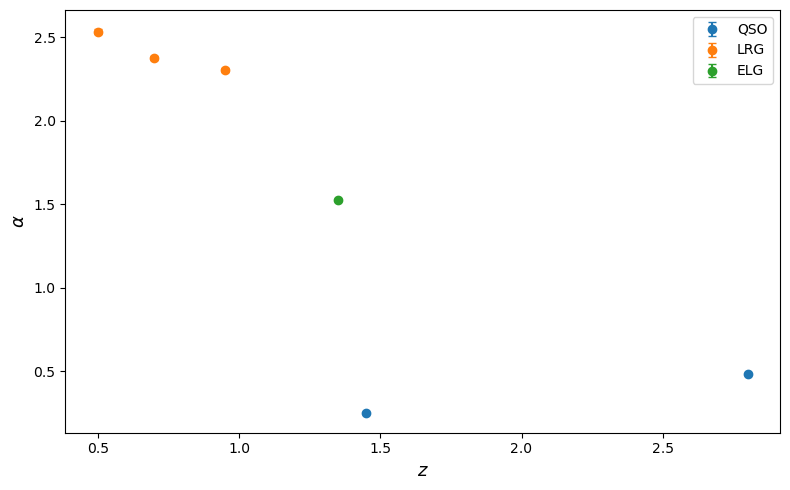

In [6]:
plt.figure(figsize=(8, 5))
for tracer_name in TRACERS:
    sub = summary_table[(summary_table["tracer"] == tracer_name) & (summary_table["region"] == "all")]
    zmid = 0.5 * (sub["zmin"] + sub["zmax"])
    plt.errorbar(zmid, sub["alpha"], yerr=sub["alpha_error"], fmt="o", capsize=3, label=tracer_name)

plt.xlabel(r"$z$", fontsize=13)
plt.ylabel(r"$\alpha$", fontsize=13)
plt.legend()
plt.tight_layout()